In [22]:
import warnings

import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from src.data_preprocessing import processed_data_fitting
import dask.dataframe as dd

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS

# hide warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing dataset
df_train = pd.read_csv("../data/cleaned/GlobalTemperaturesCleanedTrain.csv", sep = ",", index_col = "Time")
df_test = pd.read_csv("../data/cleaned/GlobalTemperaturesCleanedTest.csv", sep = ",", index_col = "Time")

In [3]:
# Processing dataset
df_train = processed_data_fitting(df_train, "GlobalTemperaturesProcessedTrain")
df_test = processed_data_fitting(df_test, "GlobalTemperaturesProcessedTest")


In [15]:
# specifying forecasting horizon
fh = ForecastingHorizon(df_test.index, is_relative=False)
fh

ForecastingHorizon(['1973-01', '1973-02', '1973-03', '1973-04', '1973-05', '1973-06',
             '1973-07', '1973-08', '1973-09', '1973-10',
             ...
             '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08',
             '2015-09', '2015-10', '2015-11', '2015-12'],
            dtype='period[M]', length=516, is_relative=False)

## Naive

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

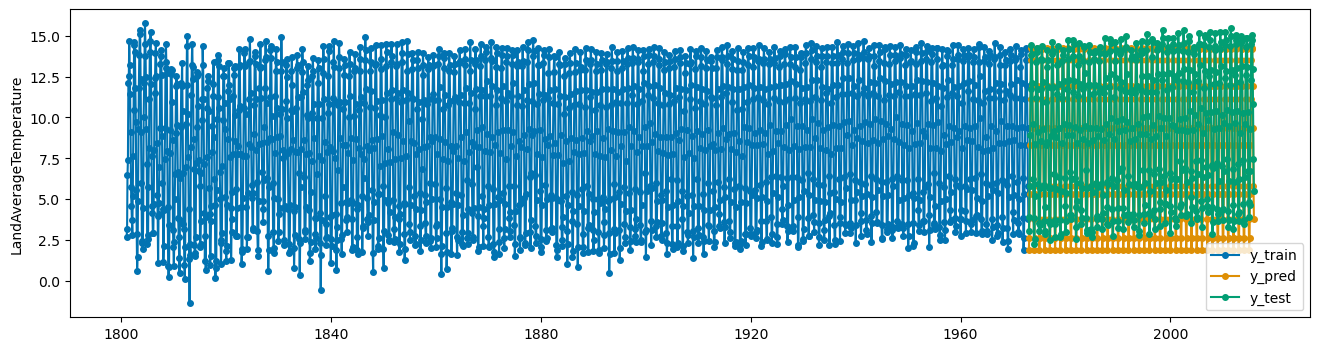

In [16]:
# specifying the forecasting algorithm
naive_forecaster = NaiveForecaster(strategy="last", sp=12) 

# fitting the forecaster
naive_forecaster.fit(df_train)

# querying predictions
y_pred_naive = naive_forecaster.predict(fh)

# plot predictions
plot_series(df_train, y_pred_naive, df_test, labels=["y_train", "y_pred", "y_test"])

In [18]:
mape = MeanAbsolutePercentageError(symmetric=False)
mape(df_test, y_pred_naive)

0.11602004596444404

# ETS

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

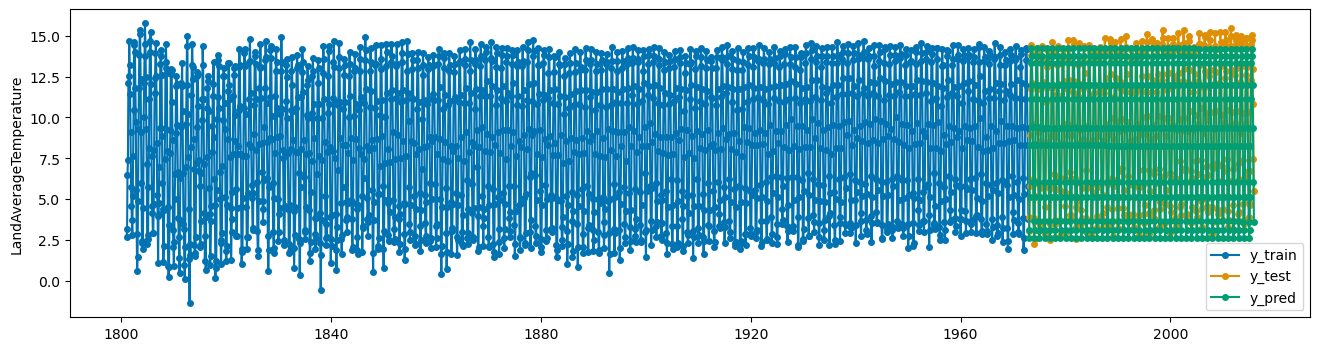

In [23]:
forecaster_exp = ExponentialSmoothing(trend="add", seasonal="additive", sp=12)
forecaster_exp.fit(df_train)
y_pred_exp = forecaster_exp.predict(fh)
plot_series(df_train, df_test, y_pred_exp, labels=["y_train", "y_test", "y_pred"])

In [24]:
mape(df_test, y_pred_exp)

0.09336951069126367

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

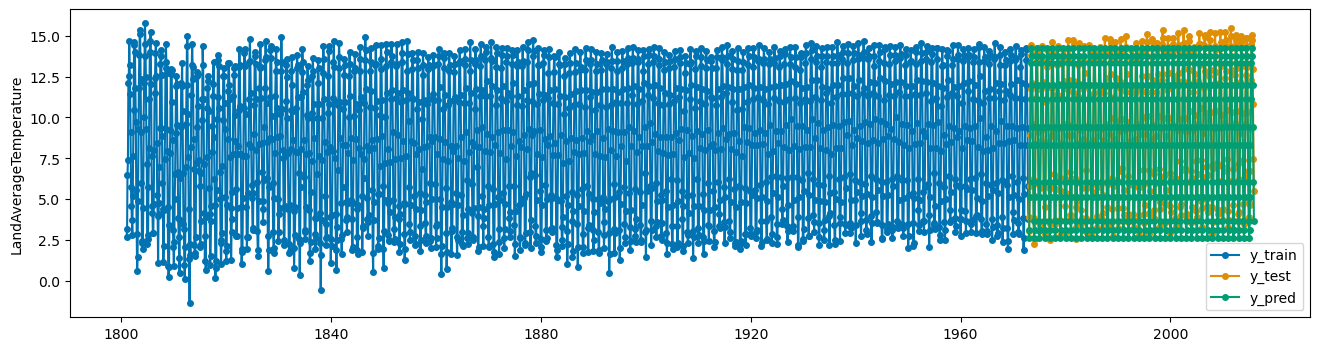

In [25]:
forecaster_ets = AutoETS(auto=True, sp=12, n_jobs=-1)
forecaster_ets.fit(df_train)
y_pred_ets = forecaster_ets.predict(fh)
plot_series(df_train, df_test, y_pred_ets, labels=["y_train", "y_test", "y_pred"])

In [26]:
mape(df_test, y_pred_ets)

0.09214673076244896